In [ ]:
from transformers import GPT2LMHeadModel

In [ ]:
import torch
x = torch.rand(5, 3)
print(x)

tensor([[0.6600, 0.0637, 0.3884],
        [0.4123, 0.9393, 0.9768],
        [0.6422, 0.0573, 0.5541],
        [0.9383, 0.1770, 0.0488],
        [0.5820, 0.0366, 0.9522]])


In [ ]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")
sd_hf = model_hf.state_dict()

for k,v in sd_hf.items():
    print(k,v.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

transformer.h.1
transformer.h.2
transformer.h.3

.

.

.

transformer.h.11 ---- These indexes represent the layer of the neural network used of Deep Learning

768 --- the dimension of the embedding

In [ ]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

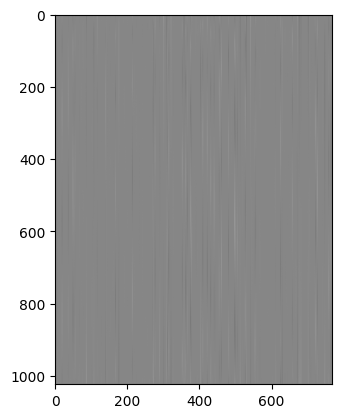

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"],cmap="gray")

From the above graph of position vector we are just considering some of the columns and plotting that specific graph

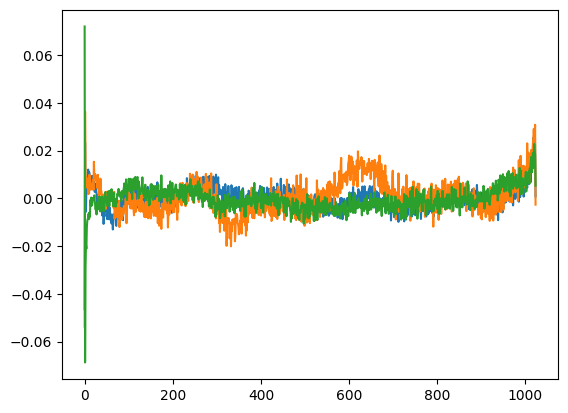

In [ ]:
plt.plot(sd_hf["transformer.wpe.weight"][:,150])
plt.plot(sd_hf["transformer.wpe.weight"][:,200])
plt.plot(sd_hf["transformer.wpe.weight"][:,350])

#the jaggedness in the graph shows that this model is not so much trained. If the plot is smooth then
# it will be a much better trained model. Contains lot of noise

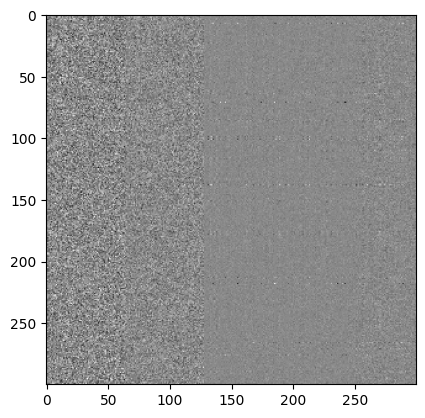

In [ ]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300,:300],cmap='gray') #a random part of a transformer

In [ ]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation',model='gpt2')
set_seed(42) #The transformers.set_seed(seed) function from Hugging Face ensures reproducibility in machine learning experiments by fixing the random seeds
generator("Hello, I am a language model,", max_length=30, num_return_sequences=5)
#num_return_sequences - number of various o/p

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello, I am a language model, I am a language model. In my mind, I am a model."\n\nWhen asked if he\'s prepared to make a big deal of it, he replied, "Yes, it\'s important." He said the project is "a chance to learn about our language and the ways that we develop it."\n\nOn the subject of the future, he added, "I am excited to see what we can do with that technology. We are using it to help us communicate more clearly and to teach language to kids. We can make things more interesting. We can develop language through a different way of thinking. We can teach languages to the child that was born in a different place and to the world. But it\'s going to take time and effort to learn different ways of thinking and to develop the language more effectively. We are going to focus more on what we are learning."\n\nThe first part of the project will focus on developing some of the technologies that could be used to develop better language.\n\n"We are going to focus on three

In [ ]:
with open('/content/GPT-2-build/input.txt','r') as f:
  text = f.read()
data = text[:1000]
print(data[:100]) #first 100 characters from the text file

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


###Tokenizing 1st 24 tokens/characters

In [ ]:
import tiktoken
enc=tiktoken.get_encoding('gpt2')
tokens=enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


###Arranging this tokens in B x T dimension so that we can feed the forward function in this dimension for batch processing of the tokens.

### inputs and outputs(labels)

In [ ]:
import torch
buf = torch.tensor(tokens[:24+1])
x=buf[:-1].view(4,6)  #creating this 2 dimensional batch
y= buf[1:].view(4,6) #creating another tensor to just create label for the the input tesnor = x
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


In [ ]:
print(sd_hf['lm_head.weight'].shape)  #channels of the transformer
print(sd_hf['transformer.wte.weight'].shape)  #weight of the tokens

torch.Size([50257, 768])
torch.Size([50257, 768])


In [ ]:
(sd_hf['lm_head.weight']==sd_hf['transformer.wte.weight']).all()  #both the tensors are having same elements

tensor(True)

### This method is generally used because its presumed that the words which are similar should have the tokens in same space/layer so we see both the tokens are identical

In [ ]:
print(sd_hf['lm_head.weight'].data_ptr())
print(sd_hf['transformer.wte.weight'].data_ptr())

134384972820435
134384972820435


##Residual streams

In [ ]:
print(torch.randn(768).shape)

torch.Size([768])


In [ ]:
#standard deviation grows inside the residual stream
x=torch.zeros(768)
n=100
for i in range(n):
  x+=n**-0.5 * torch.randn(768) #simulating residual stream and then controlling the variance inside activation in residual streams
print(x.std())

tensor(1.0192)


In [1]:
%load_ext colabxterm
%xterm

Launching Xterm...

<IPython.core.display.Javascript object>